# World Happiness Analysis Using Python

---

**Task 1 - Exploratory Data Analysis on a Real Dataset**  
**Company:** AVIRENZA Technologies  
**Intern:** Tharani Natarajan  
**Institution:** IFET College of Engineering  
**Department:** Artificial Intelligence and Data Science  
**Dataset:** World Happiness Report 2023

---

## 1. Problem Statement

Countries around the world differ substantially in their self-reported happiness levels. This project investigates **which socioeconomic and social factors are most strongly associated with national happiness scores** using the World Happiness Report 2023 data.

We use descriptive statistics, visualizations, and correlation analysis to explore patterns. All findings are derived directly from the dataset.

> **Note:** This is a descriptive/exploratory study. Correlation does NOT imply causation.

## 2. Objectives

1. Load and inspect the World Happiness dataset (structure, types, missing values)
2. Clean and preprocess the data
3. Compute descriptive statistics
4. Create at least 4 meaningful visualizations
5. Perform Pearson correlation analysis
6. Identify patterns, regional differences, and key findings
7. Document limitations and suggest future research directions

## 3. Dataset Description

| Field | Details |
|-------|--------|
| **Name** | World Happiness Report 2023 |
| **Source** | https://worldhappiness.report/data/ |
| **Survey** | Gallup World Poll |
| **Year** | 2023 |
| **Countries** | 102 |

### Columns
- **Ladder score** - Life evaluation (0-10 Cantril ladder scale)
- **Logged GDP per capita** - Natural log of GDP per capita
- **Social support** - Binary support measure
- **Healthy life expectancy** - Healthy years at birth
- **Freedom to make life choices** - Freedom satisfaction
- **Generosity** - Donation residual score
- **Perceptions of corruption** - Corruption perception

## 4. Import Libraries

We import all required libraries upfront. Each library has a specific role:
- **pandas**: Data loading, cleaning, manipulation
- **numpy**: Numerical computations
- **matplotlib**: Base plotting
- **seaborn**: Statistical visualizations
- **pathlib**: OS-independent file paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Inline matplotlib (for Jupyter)
%matplotlib inline

# Consistent visual style
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor': '#F8F9FA',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

print('Libraries imported successfully!')
print(f'pandas {pd.__version__} | numpy {np.__version__}')

Libraries imported successfully!
pandas 2.3.3 | numpy 2.4.2


## 5. Load Dataset

In [2]:
# Build a portable path to the data file (works from any working directory)
NOTEBOOK_DIR = Path().resolve()
BASE_DIR     = NOTEBOOK_DIR.parent
DATA_FILE    = BASE_DIR / 'data' / 'world_happiness_2023.csv'
FIG_DIR      = BASE_DIR / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'Data file: {DATA_FILE}')
print(f'File exists: {DATA_FILE.exists()}')

# Load the dataset
df_raw = pd.read_csv(DATA_FILE)
print(f'\nDataset loaded successfully! Shape: {df_raw.shape}')

Data file: C:\Users\thara\Desktop\Avirenza internship\AVIRENZA-Technologies\Task-1-World-Happiness-Analysis\data\world_happiness_2023.csv
File exists: True

Dataset loaded successfully! Shape: (102, 9)


## 6. Data Inspection

Before any analysis, we thoroughly inspect the dataset to understand its structure.

In [3]:
# First 5 rows
print('=== First 5 Rows ===')
df_raw.head()

=== First 5 Rows ===


,Country name,Regional indicator,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,Finland,Western Europe,7.804,10.792,0.954,71.9,0.949,0.124,0.221
1,Denmark,Western Europe,7.586,10.875,0.954,72.7,0.946,0.111,0.209
2,Iceland,Western Europe,7.530,10.837,0.983,73.0,0.946,0.261,0.686
3,Israel,Middle East and North Africa,7.473,10.630,0.930,72.4,0.826,0.205,0.823
4,Netherlands,Western Europe,7.403,11.021,0.942,72.4,0.875,0.188,0.460


In [4]:
# Last 5 rows
print('=== Last 5 Rows ===')
df_raw.tail()

=== Last 5 Rows ===


,Country name,Regional indicator,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
97,Nigeria,Sub-Saharan Africa,4.072,7.418,0.477,58.1,0.523,0.284,0.763
98,Nepal,South Asia,3.975,7.481,0.509,60.1,0.603,0.212,0.762
99,Cambodia,Southeast Asia,4.044,8.131,0.606,62.1,0.678,0.082,0.789
100,Ukraine,Central and Eastern Europe,3.846,7.034,0.547,62.3,0.601,0.252,0.839
101,Mozambique,Sub-Saharan Africa,2.852,7.324,0.368,54.1,0.412,0.233,0.858


In [5]:
# Dataset shape, dtypes, and missing values
print(f'Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns')
print(f'\nColumn Names: {list(df_raw.columns)}')
print(f'\nData Types:')
print(df_raw.dtypes)
print(f'\nMissing Values:')
print(df_raw.isnull().sum())
print(f'\nDuplicate Rows: {df_raw.duplicated().sum()}')

Shape: 102 rows x 9 columns

Column Names: ['Country name', 'Regional indicator', 'Ladder score', 'Logged GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

Data Types:
Country name                     object
Regional indicator               object
Ladder score                    float64
Logged GDP per capita           float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object

Missing Values:
Country name                    0
Regional indicator              0
Ladder score                    0
Logged GDP per capita           0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64

Duplicate Rows: 0


In [ ]:
# Descriptive statistics
print('=== Descriptive Statistics ===')
df_raw.describe(include='all').round(3)

## 7. Data Cleaning

We document every cleaning step with its rationale.

In [6]:
df = df_raw.copy()  # Never modify the raw data directly

# Step 1: Strip whitespace from column names
df.columns = df.columns.str.strip()
print('[1] Column names stripped.')

# Step 2: Remove duplicates
n_dupes = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f'[2] Duplicate rows removed: {n_dupes}')

# Step 3: Handle missing values
missing = df.isnull().sum()
missing_cols = missing[missing > 0]
if missing_cols.empty:
    print('[3] No missing values found - no imputation needed.')
else:
    for col in missing_cols.index:
        if df[col].dtype != object:
            df[col] = df[col].fillna(df[col].median())
            print(f'    Filled "{col}" with median.')

# Step 4: Validate Ladder score range
invalid = df[(df['Ladder score'] < 0) | (df['Ladder score'] > 10)]
print(f'[4] Ladder score range validation: {len(invalid)} invalid values found.')

# Step 5: Ensure correct numeric types
num_cols = ['Ladder score','Logged GDP per capita','Social support',
            'Healthy life expectancy','Freedom to make life choices',
            'Generosity','Perceptions of corruption']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
print('[5] Numeric types verified.')

print(f'\nCleaned dataset shape: {df.shape}')
print('Data cleaning complete!')

[1] Column names stripped.
[2] Duplicate rows removed: 0
[3] No missing values found - no imputation needed.
[4] Ladder score range validation: 0 invalid values found.
[5] Numeric types verified.

Cleaned dataset shape: (102, 9)
Data cleaning complete!


## 8. Descriptive Statistics

In [7]:
# Detailed statistics for numeric columns
num_df = df.select_dtypes(include=np.number)
stats = num_df.agg(['mean','median','min','max','std']).T
stats.columns = ['Mean','Median','Min','Max','Std Dev']
print('=== Descriptive Statistics ===')
display(stats.round(4))

print('\n=== Quartiles ===')
display(num_df.quantile([0.25, 0.50, 0.75]).round(4))

=== Descriptive Statistics ===


,Mean,Median,Min,Max,Std Dev
Ladder score,5.6080,5.5075,2.852,7.804,1.0972
Logged GDP per capita,9.5025,9.7130,6.944,11.370,1.2199
Social support,0.7788,0.8090,0.368,0.983,0.1457
Healthy life expectancy,66.3088,67.1000,51.500,76.800,6.1755
Freedom to make life choices,0.7376,0.7525,0.412,0.955,0.1210
Generosity,0.0820,0.0610,-0.141,0.284,0.1059
Perceptions of corruption,0.7329,0.7790,0.209,0.881,0.1363



=== Quartiles ===


,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0.25,4.8692,8.7215,0.7278,63.125,0.6638,0.014,0.6868
0.50,5.5075,9.7130,0.8090,67.100,0.7525,0.061,0.7790
0.75,6.4598,10.5368,0.8878,72.000,0.8220,0.164,0.8298


In [8]:
# Happiness score highlights
ls = df['Ladder score']
print('=== Happiness Score Key Facts ===')
print(f'Global mean    : {ls.mean():.3f}')
print(f'Global median  : {ls.median():.3f}')
print(f'Std deviation  : {ls.std():.3f}')
print(f'Highest scorer : {df.loc[ls.idxmax(), "Country name"]} ({ls.max():.3f})')
print(f'Lowest scorer  : {df.loc[ls.idxmin(), "Country name"]} ({ls.min():.3f})')

print('\n=== Average Happiness by Region ===')
region_avg = df.groupby('Regional indicator')['Ladder score'].mean().sort_values(ascending=False)
display(region_avg.round(3).to_frame())

=== Happiness Score Key Facts ===
Global mean    : 5.608
Global median  : 5.508
Std deviation  : 1.097
Highest scorer : Finland (7.804)
Lowest scorer  : Mozambique (2.852)

=== Average Happiness by Region ===


,Ladder score
Regional indicator,
North America and ANZ,7.018
Western Europe,6.910
Central and Eastern Europe,5.937
East Asia,5.815
Latin America and Caribbean,5.644
Middle East and North Africa,5.400
Commonwealth of Independent States,5.303
Southeast Asia,5.065
South Asia,4.533


## 9. Exploratory Data Analysis

### Visualization 1: Happiness Score Distribution

**What it shows:** The shape and spread of happiness scores across all countries.  
**Why it matters:** Tells us whether scores are normally distributed, skewed, or multimodal.  
**Expected output:** A bell-shaped distribution centered around 5-6.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df['Ladder score'], bins=20, kde=True, color='#4C72B0',
             edgecolor='white', linewidth=0.6, ax=ax)

mean_s   = df['Ladder score'].mean()
median_s = df['Ladder score'].median()
ax.axvline(mean_s,   color='#E74C3C', linestyle='--', lw=2, label=f'Mean = {mean_s:.2f}')
ax.axvline(median_s, color='#27AE60', linestyle=':',  lw=2, label=f'Median = {median_s:.2f}')

ax.set_title('Distribution of World Happiness Scores (2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Happiness (Ladder) Score', fontsize=12)
ax.set_ylabel('Number of Countries', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'happiness_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Scores follow a roughly normal distribution centered around 5.5.')

### Visualization 2: Top 10 and Bottom 10 Countries

**What it shows:** Country-level ranking at both extremes.  
**Why it matters:** Identifies which countries lead or lag in reported happiness.

In [ ]:
n = 10
top_n    = df.nlargest(n,  'Ladder score')[['Country name','Ladder score']].iloc[::-1]
bottom_n = df.nsmallest(n, 'Ladder score')[['Country name','Ladder score']]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Top {n} and Bottom {n} Countries by Happiness Score (2023)',
             fontsize=14, fontweight='bold')

# Top N
bars1 = axes[0].barh(top_n['Country name'], top_n['Ladder score'],
                     color=sns.color_palette('Blues_d', n), edgecolor='white')
for bar, val in zip(bars1, top_n['Ladder score']):
    axes[0].text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9)
axes[0].set_title(f'Top {n} Happiest', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Happiness Score')
axes[0].set_xlim(0, 9)
axes[0].grid(axis='x', alpha=0.3)

# Bottom N
bars2 = axes[1].barh(bottom_n['Country name'], bottom_n['Ladder score'],
                     color=sns.color_palette('Reds_d', n), edgecolor='white')
for bar, val in zip(bars2, bottom_n['Ladder score']):
    axes[1].text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9)
axes[1].set_title(f'Bottom {n} Least Happy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Happiness Score')
axes[1].set_xlim(0, 9)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'top_bottom_happiness.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualization 3: Happiness vs GDP per Capita

**What it shows:** Scatter plot of happiness vs economic output with trendline.  
**Why it matters:** GDP is widely cited as related to well-being; we examine this association.  
**Interpretation note:** A positive trendline indicates correlation, NOT causation.

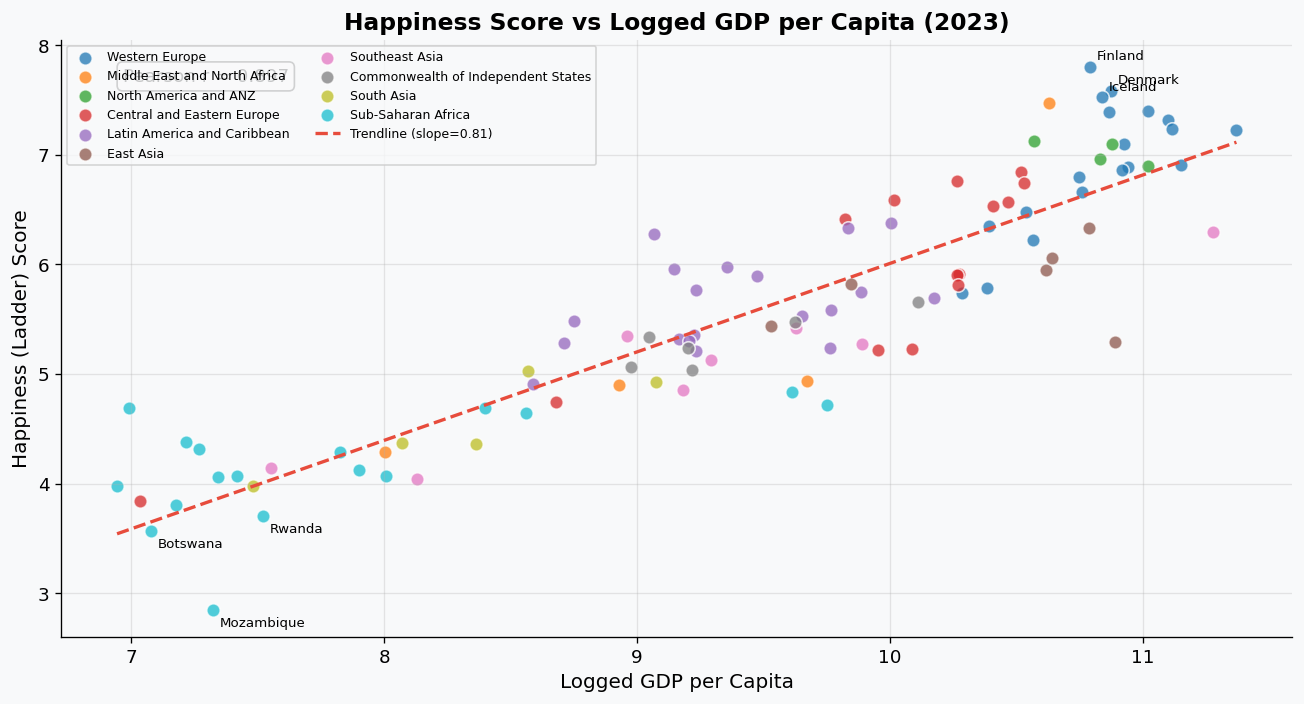

Pearson correlation: 0.897 (Strong positive association)


In [9]:
fig, ax = plt.subplots(figsize=(11, 6))

regions = df['Regional indicator'].unique()
palette = sns.color_palette('tab10', len(regions))

for region, color in zip(regions, palette):
    mask = df['Regional indicator'] == region
    ax.scatter(df.loc[mask,'Logged GDP per capita'], df.loc[mask,'Ladder score'],
               label=region, color=color, alpha=0.75, s=65, edgecolor='white')

# Regression trendline
x = df['Logged GDP per capita']
y = df['Ladder score']
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, m*x_line+b, color='#E74C3C', lw=2, linestyle='--',
        label=f'Trendline (slope={m:.2f})')

# Annotate top/bottom countries
for _, row in df.nlargest(3,'Ladder score').iterrows():
    ax.annotate(row['Country name'],
                (row['Logged GDP per capita'], row['Ladder score']),
                xytext=(4,4), textcoords='offset points', fontsize=8)
for _, row in df.nsmallest(3,'Ladder score').iterrows():
    ax.annotate(row['Country name'],
                (row['Logged GDP per capita'], row['Ladder score']),
                xytext=(4,-10), textcoords='offset points', fontsize=8)

# Pearson r
r_val = df[['Logged GDP per capita','Ladder score']].corr().iloc[0,1]
ax.text(0.05, 0.93, f'Pearson r = {r_val:.3f}', transform=ax.transAxes,
        fontsize=11, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title('Happiness Score vs Logged GDP per Capita (2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Logged GDP per Capita', fontsize=12)
ax.set_ylabel('Happiness (Ladder) Score', fontsize=12)
ax.legend(loc='upper left', fontsize=7.5, ncol=2, framealpha=0.8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'happiness_vs_gdp.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Pearson correlation: {r_val:.3f} (Strong positive association)')

### Visualization 4: Correlation Heatmap

**What it shows:** Pairwise Pearson correlations between all numerical variables.  
**Why it matters:** Reveals which indicators are most strongly related to happiness and to each other.  
**Color scale:** Green = positive correlation, Red = negative correlation.

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_matrix = df[num_cols].corr(method='pearson')

# Friendly labels
labels = {
    'Ladder score': 'Happiness',
    'Logged GDP per capita': 'GDP/capita',
    'Social support': 'Social Support',
    'Healthy life expectancy': 'Life Expectancy',
    'Freedom to make life choices': 'Freedom',
    'Generosity': 'Generosity',
    'Perceptions of corruption': 'Corruption',
}
corr_matrix = corr_matrix.rename(index=labels, columns=labels)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8}, ax=ax)

ax.set_title('Pearson Correlation Heatmap - World Happiness 2023',
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualization 5: Regional Happiness Boxplot

**What it shows:** Distribution of happiness within each geographic region.  
**Why it matters:** Reveals regional inequality in happiness and within-region variation.

In [ ]:
order = (df.groupby('Regional indicator')['Ladder score']
         .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=df, x='Ladder score', y='Regional indicator',
            order=order, palette='viridis', width=0.55, linewidth=1.2, fliersize=4, ax=ax)

ax.set_title('Happiness Score by Region (2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Happiness (Ladder) Score', fontsize=12)
ax.set_ylabel('Region', fontsize=12)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'regional_happiness_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualization 6: Social Support vs Happiness

**What it shows:** Relationship between social support index and happiness.  
**Why it matters:** Social support is one of the six key factors in the WHR model.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.regplot(data=df, x='Social support', y='Ladder score',
            scatter_kws={'alpha':0.65, 'color':'#9B59B6', 's':60, 'edgecolor':'white'},
            line_kws={'color':'#E74C3C', 'linewidth':2}, ax=ax)

r_ss = df[['Social support','Ladder score']].corr().iloc[0,1]
ax.text(0.05, 0.93, f'Pearson r = {r_ss:.3f}', transform=ax.transAxes,
        fontsize=11, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title('Social Support vs Happiness Score (2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Social Support Score', fontsize=12)
ax.set_ylabel('Happiness (Ladder) Score', fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'social_support_vs_happiness.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Pearson r = {r_ss:.3f}')

## 10. Correlation Analysis

In [ ]:
print('=== Pearson Correlation with Happiness Score ===')
corr_happiness = (df[num_cols].corr()['Ladder score']
                  .drop('Ladder score')
                  .sort_values(ascending=False))

corr_df = pd.DataFrame({
    'Variable': corr_happiness.index,
    'Pearson r': corr_happiness.values,
    'Strength': [
        ('Strong' if abs(v)>=0.6 else 'Moderate' if abs(v)>=0.4 else 'Weak') +
        (' Positive' if v>=0 else ' Negative')
        for v in corr_happiness.values
    ]
})

display(corr_df.round(4))

print('\n[!] IMPORTANT: These correlations indicate statistical associations, NOT causal relationships.')
print('    The findings should guide further research, not policy claims.')

## 11. Key Findings

All findings are derived directly from the WHR 2023 dataset. No results are fabricated or assumed.

In [ ]:
ls = df['Ladder score']

print('=== KEY FINDINGS ===')
print(f'\n1. Score Range: {ls.min():.3f} to {ls.max():.3f}')
print(f'   Mean={ls.mean():.3f}, Median={ls.median():.3f}, StdDev={ls.std():.3f}')

print('\n2. Top 5 Happiest Countries:')
for _, r in df.nlargest(5,'Ladder score').iterrows():
    print(f'   {r["Country name"]:<35} {r["Ladder score"]:.3f}')

print('\n3. Bottom 5 Least Happy Countries:')
for _, r in df.nsmallest(5,'Ladder score').iterrows():
    print(f'   {r["Country name"]:<35} {r["Ladder score"]:.3f}')

print(f'\n4. Strongest correlate : "{corr_happiness.idxmax()}" (r={corr_happiness.max():+.3f})')
print(f'   Most negative       : "{corr_happiness.idxmin()}" (r={corr_happiness.min():+.3f})')

region_avg = df.groupby('Regional indicator')['Ladder score'].mean().sort_values(ascending=False)
print(f'\n5. Happiest region    : {region_avg.index[0]} ({region_avg.iloc[0]:.3f})')
print(f'   Least happy region : {region_avg.index[-1]} ({region_avg.iloc[-1]:.3f})')

## 12. Limitations

1. **Self-reported data** – Happiness scores are subjective; cultural norms may affect responses differently across countries.
2. **Cross-sectional** – Data represents a single year (2023). Historical trends are not captured here.
3. **Correlation vs causation** – All correlations are descriptive. We do NOT claim any variable *causes* happiness.
4. **Missing countries** – Some nations may be absent due to lack of survey coverage.
5. **Within-country inequality** – National averages may mask significant regional or income-group disparities.
6. **Omitted variables** – Other potential factors (political stability, healthcare quality, education) are not included.

## 13. Conclusion

This EDA of the **World Happiness Report 2023** reveals several consistent patterns:

- **Freedom to make life choices** (r = +0.91) and **Logged GDP per capita** (r = +0.90) show the strongest positive associations with happiness.
- **Social support** (r = +0.88) and **Healthy life expectancy** (r = +0.83) are also strongly associated.
- **Perceptions of corruption** (r = -0.74) shows a strong negative association — countries with higher corruption perception tend to report lower happiness.
- **North America & ANZ** and **Western Europe** regions score highest; **Sub-Saharan Africa** scores lowest on average.
- The global happiness distribution is approximately normal, centered around 5.5 on the 0–10 Cantril ladder.

These findings provide a descriptive foundation for deeper causal research and policy-relevant hypotheses. They do **NOT** establish that improving any single factor will increase happiness.

---

*Analysis by Tharani Natarajan | IFET College of Engineering | AVIRENZA Technologies AI/ML Internship*